# 单车骑行流量分布

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [1]:
#np.save("traffic(bj)",traffic)

In [3]:
traffic=(np.load("traffic(bj).npy")).tolist()#单向流动区域的单车流量（先对每条骑行记录的起始、终点所在区域进行判定，通过统计得到任意区域对之间只有单向流动的区域流量）

In [2]:
#np.save("traffic_(bj)",traffic_)

In [4]:
traffic_=(np.load("traffic_(bj).npy")).tolist()#双向流动区域的单车流量（通过统计得到任意区域对之间双向流动的单车流量）

In [5]:
traffic2=[]
traffic2.extend(traffic)
traffic2.extend(traffic_)

In [6]:
traffic3=pd.Series(traffic2)
t_n=traffic3.value_counts()   #流量数目的统计
t_n1=(t_n.index).tolist()
t_n2=(t_n.values).tolist()
dic=dict(zip(t_n1,t_n2))
t_n1.sort()


In [7]:
t_n2=[]
for i in t_n1:
    t_n2.append(dic[i])

In [8]:
def log_pdf(x,y):
    bins=np.logspace(0, 4, 20)
    bins2=list(bins)
    bins_all={}
    for i in range(len(bins)-1):
        bins_all[bins[i]]=[]
    widths = (bins[1:] - bins[:-1])
    for i in range(len(x)):
        for j in range(len(bins)):
            if(x[i]<bins[j]):
                bins_all[bins[j-1]].append(y[i])
                break
            if(x[i]==bins[j]):
                bins_all[bins[j]].append(y[i])
                break
    x_new=[]
    y_new=[]
    for key,value in bins_all.items():
        if(len(value)>0):
            index_this=bins2.index(key)
            y_new.append(np.sum(value)/widths[index_this])
#            y_new.append(np.mean(value))
            x_new.append(key)
        
    return x_new,y_new

In [9]:
a,b=log_pdf(t_n1,t_n2)

In [10]:
t_n11=[]
for i in range(0,len(a)):
    z=a[i]
    t_n11.append(round(math.log10(z),2))

In [11]:
t_n22=[]
for i in range(0,len(b)):
    z=b[i]
    t_n22.append(round(math.log10(z),2))

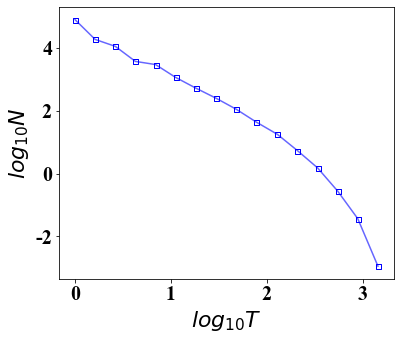

In [13]:
fig= plt.figure(figsize=(6,5))          #总流量
ax = fig.add_subplot(1,1,1) 
#plt.bar(range(len(t_n1)), t_n2,color='blue',tick_label=t_n1,alpha=0.5)
ax.scatter(t_n11,t_n22,marker = 's',color="w",linewidths=1,s=25,edgecolors='blue')
plt.plot(t_n11,t_n22,color='blue',alpha=0.6)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("$log_{10}N$",size=22,family='Times New Roman')  
ax.set_xlabel("$log_{10}T$",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)
plt.show()

In [13]:
def f_1(x, A, B):
    return A * x + B
x0 =t_n11
y0 =t_n22
A1, B1 = optimize.curve_fit(f_1, x0, y0)[0]
x1 = np.arange(min(t_n11),max(t_n11), 0.01)#30和75要对应x0的两个端点，0.01为步长
y1 = A1 * x1 + B1

In [14]:
print(A1)
print(B1)

-2.127263709628751
5.19216758157639


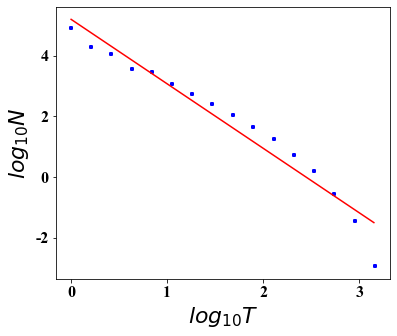

In [15]:
fig= plt.figure(figsize=(6,5))          
ax = fig.add_subplot(1,1,1) 
#plt.bar(range(len(t_n1)), t_n2,color='blue',tick_label=t_n1,alpha=0.5)
ax.scatter(t_n11,t_n22,marker = 's',color="w",linewidths=2,s=5,edgecolors='blue')
plt.plot(x1,y1,color='red')
#ax.set_xscale("log")
#ax.set_yscale("log")
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("$log_{10}N$",size=22,family='Times New Roman')  
ax.set_xlabel("$log_{10}T$",size=22,family='Times New Roman')
plt.tick_params(labelsize=16)
plt.show()
#plt.savefig('双向区域对流量分布.pdf')